In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/train_1.csv')
valid = pd.read_csv('/content/drive/MyDrive/valid.csv')
test  = pd.read_csv('/content/drive/MyDrive/test.csv')

print('Train size:', train.shape)
print('Valid size:', valid.shape)
print('Test  size:', test.shape)

Train size: (2930, 2)
Valid size: (366, 2)
Test  size: (366, 2)


In [ ]:
# Instead of 0,1,2,3,4 the charts show Diabetic Retinopathy Disease Severity Scale
stage_names = {
    0: 'No DR',
    1: 'Mild DR',
    2: 'Moderate DR',
    3: 'Severe DR',
    4: 'Proliferative DR'
}

train['stage'] = train['diagnosis'].map(stage_names)
valid['stage'] = valid['diagnosis'].map(stage_names)
test['stage']  = test['diagnosis'].map(stage_names)

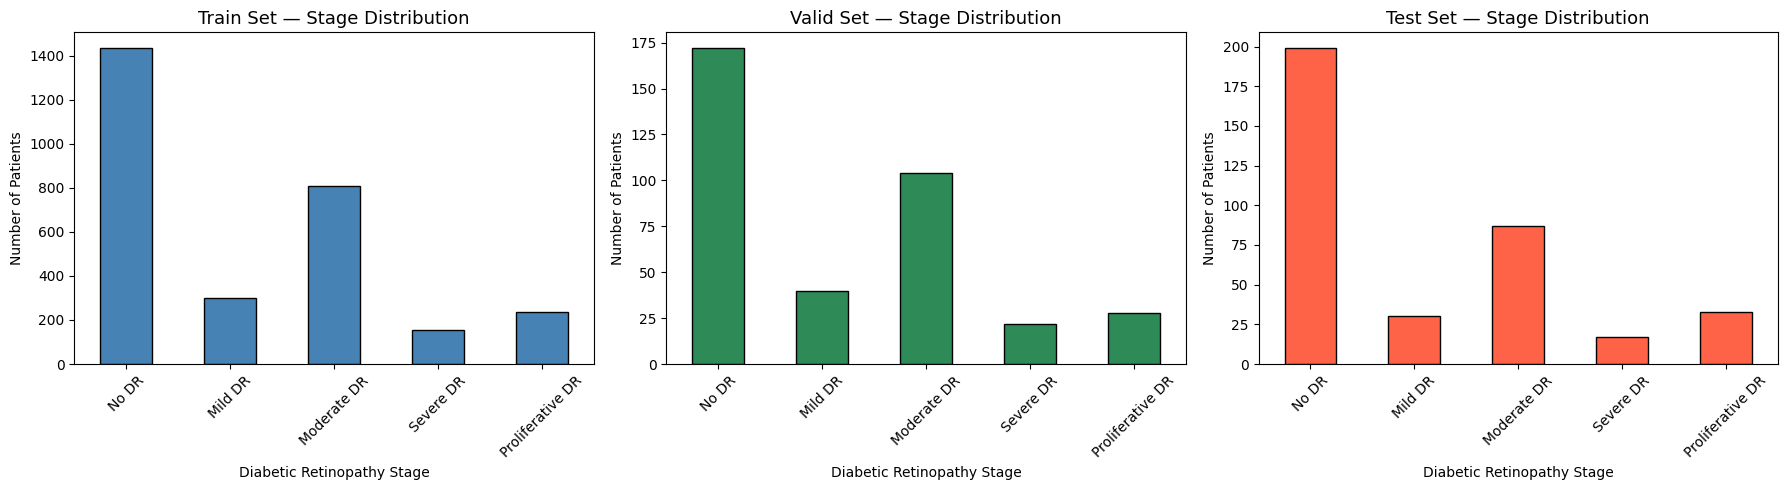

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets     = [train,   valid,   test]
dataset_names = ['Train', 'Valid', 'Test']
colors        = ['steelblue', 'seagreen', 'tomato']

for ax, data, name, color in zip(axes, datasets, dataset_names, colors):
    counts = data['stage'].value_counts().reindex(stage_names.values())
    counts.plot(kind='bar', ax=ax, color=color, edgecolor='black')
    ax.set_title(f'{name} Set — Stage Distribution', fontsize=13)
    ax.set_xlabel('Diabetic Retinopathy Stage')
    ax.set_ylabel('Number of Patients')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bar_charts.png')  # saves to your Drive
plt.show()

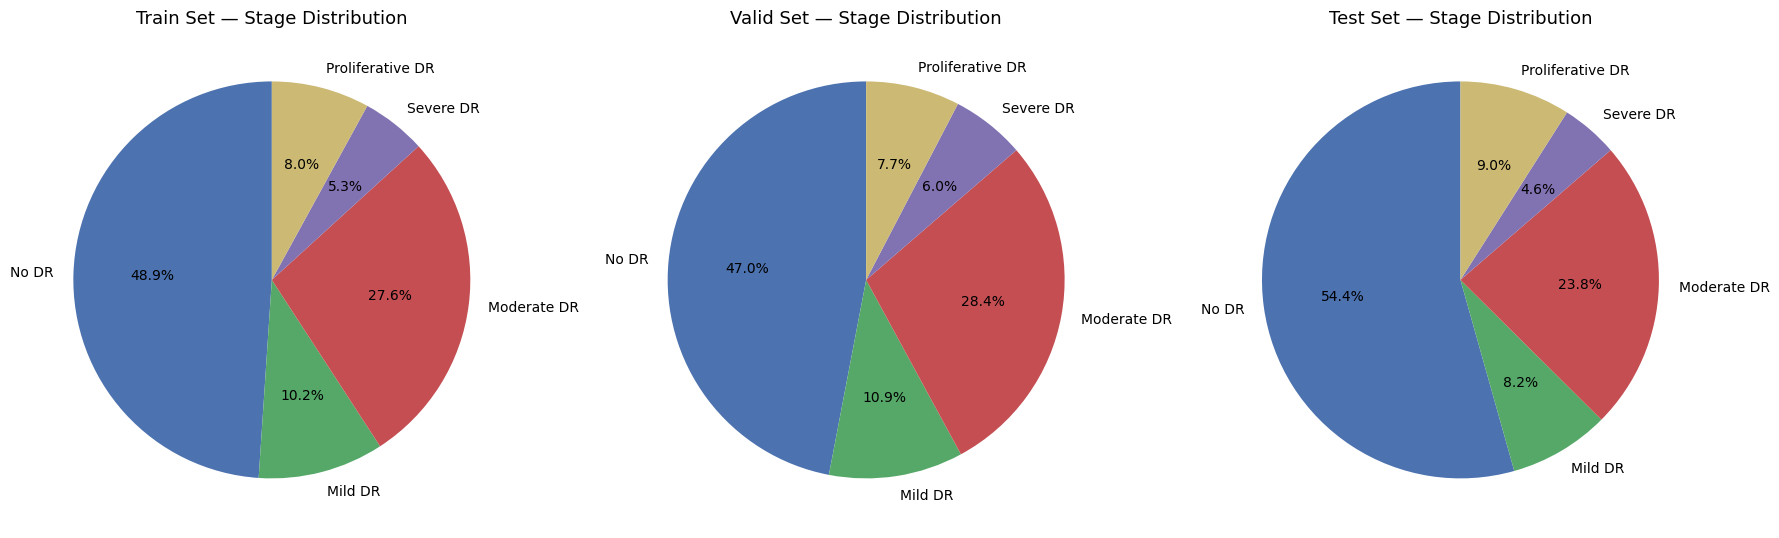

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, data, name in zip(axes, datasets, dataset_names):
    counts = data['stage'].value_counts().reindex(stage_names.values())
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',        # shows percentage on each slice
        startangle=90,
        colors=['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
    )
    ax.set_title(f'{name} Set — Stage Distribution', fontsize=13)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pie_charts.png')  # saves to your Drive
plt.show()

In [ ]:
summary = pd.DataFrame({
    'Train' : train['stage'].value_counts().reindex(stage_names.values()),
    'Valid'  : valid['stage'].value_counts().reindex(stage_names.values()),
    'Test'   : test['stage'].value_counts().reindex(stage_names.values())
})

print(summary)

                  Train  Valid  Test
stage                               
No DR              1434    172   199
Mild DR             300     40    30
Moderate DR         808    104    87
Severe DR           154     22    17
Proliferative DR    234     28    33
